### Load  and First Inspection of the Dataset

In [2]:
import pandas as pd

# This tells pandas not to wrap the table into multiple chunks
pd.set_option('display.expand_frame_repr', False)

df = pd.read_csv('sample.csv')

print(f"First 5 rows:\n{df.head()}\n")

print(f"DataFrame Info:")
df.info()
print()

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}\n")

print(f"DataFrame Description:\n{df.describe()}")

First 5 rows:
   sensor_id        sensor_name        utm_x        utm_y  magnitude_id magnitude_name           entry_date      value  is_interpolated
0   28079008   Escuelas Aguirre  442117.2366  4474770.696            12            NOX  2006-08-16 01:00:00  56.000000            False
1   28079039   Barrio del Pilar  439689.0496  4481081.619            88             RS  2024-03-21 05:00:00   1.045836             True
2   28079057        Sanchinarro  444026.8080  4482820.581          1023         OC_IDW  2020-03-13 00:00:00   0.000000            False
3   28079049  Parque del Retiro  442095.5200  4473981.740            89  PRECIPITACION  2021-01-30 04:00:00   0.000000             True
4   28079060        Tres Olivos  441556.7005  4483543.994          1023         OC_IDW  2023-12-19 09:00:00  15.933061            False

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ---

### Inspecting Categorical Columns

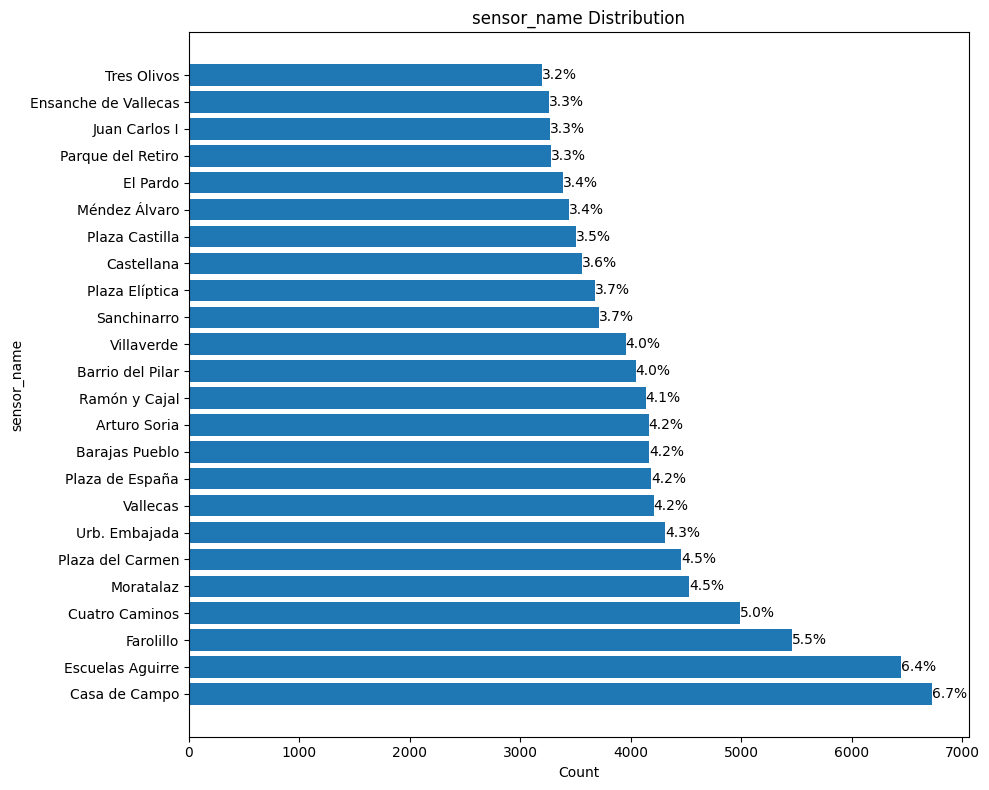

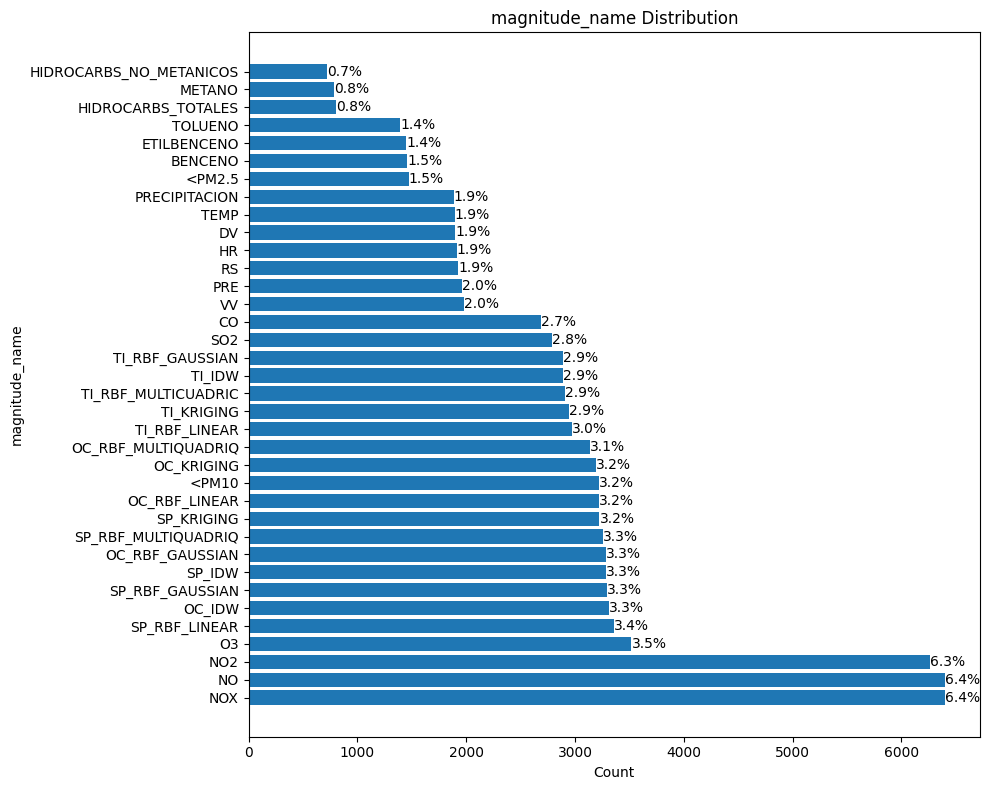

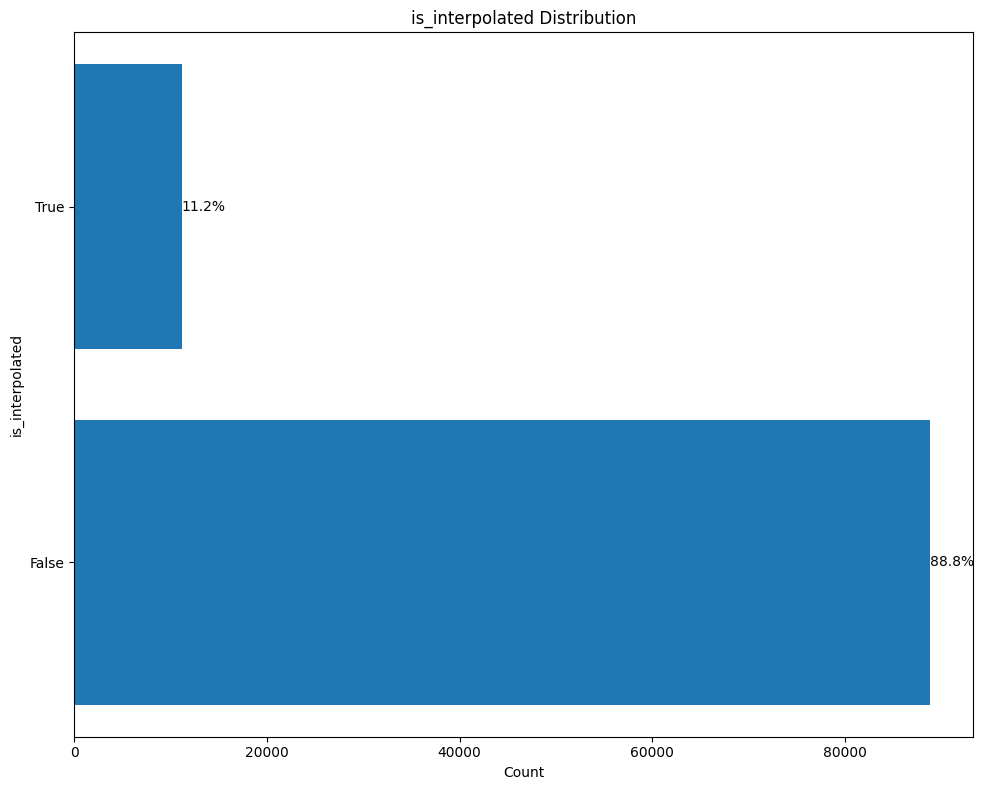

In [3]:
import matplotlib.pyplot as plt

def plot_categorical_distribution_horizontal(df, column, top_n=None, figsize=(10, 8)):
    # Count values (including NaN)
    counts = df[column].value_counts(dropna=False)
    
    # Optionally limit to top N categories
    if top_n:
        counts = counts.head(top_n)
    
    # Convert labels to string (so NaN shows as "nan")
    labels = counts.index.astype(str)
    values = counts.values
    total = values.sum()
    
    # Create horizontal bar chart
    plt.figure(figsize=figsize)
    bars = plt.barh(labels, values)
    
    # Add percentage labels
    for bar, value in zip(bars, values):
        percentage = (value / total) * 100
        plt.text(
            bar.get_width(),                      # x position
            bar.get_y() + bar.get_height() / 2,   # y position
            f"{percentage:.1f}%",
            va='center'
        )
    
    # Labels and title
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.title(f"{column} Distribution")
    
    plt.tight_layout()
    plt.show()

plot_categorical_distribution_horizontal(df, "sensor_name")
plot_categorical_distribution_horizontal(df, "magnitude_name")
plot_categorical_distribution_horizontal(df, "is_interpolated")



### Exploring Numerical Columns

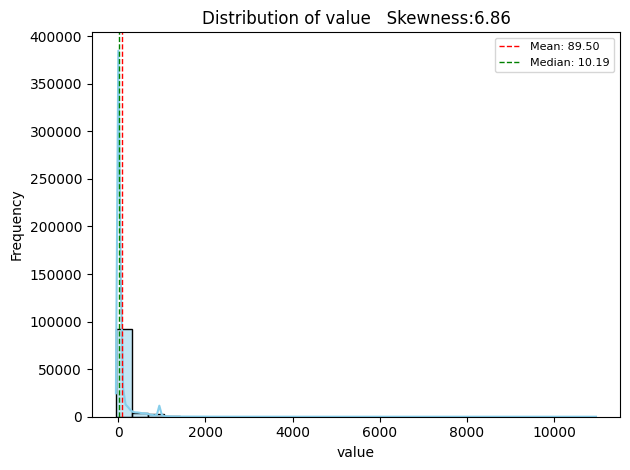

In [4]:
from scipy.stats import skew
import seaborn as sns

def plot_numeric_distributions(data, numeric_column, bins=30):
    """
    Plots the distributions of numeric columns with KDE, including skewness and summary stats.
    """

    plt.figure()  # Adjust figure height dynamically
        
    # Add mean and median and skewness
    mean_val = data[numeric_column].mean()
    median_val = data[numeric_column].median()
    skewness = skew(data[numeric_column].dropna())
    
    # Plot histogram with KDE
    sns.histplot(data[numeric_column], kde=True, bins=bins, color="skyblue", edgecolor="black")
    
    # Add title and labels
    plt.title(f'Distribution of {numeric_column}   Skewness:{skewness:.2f}', fontsize=12)
    plt.xlabel(numeric_column, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    
    # Add mean and median as vertical lines
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Median: {median_val:.2f}')
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# Call the function
plot_numeric_distributions(df, "value")

# x_col='utm_x'
# y_col='utm_y'
# plt.figure(figsize=(8, 8))

# plt.scatter(df[x_col], df[y_col], alpha=0.3)

# plt.xlabel(x_col)
# plt.ylabel(y_col)
# plt.title("Sensor Locations (Scatter Plot)")

# plt.tight_layout()
# plt.show()


### Timeline

--- Timeline Details ---
Start Date: 2001-01-01 10:00:00
End Date:   2024-12-31 20:00:00
Duration:   23 years, 11 months, 30 days (Total: 8765 days)
------------------------


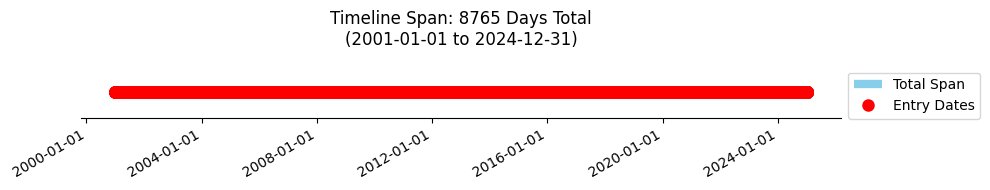

In [6]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.dates as mdates

def plot_timeline_span(date_strings):
    """
    Takes a list of datetime strings, calculates the span, 
    and plots a 1D timeline showing the entries and total duration.
    """
    # 1. Convert string dates to datetime objects
    date_format = "%Y-%m-%d %H:%M:%S"
    dates = [datetime.strptime(date_str, date_format) for date_str in date_strings]
    
    # 2. Find the span (min and max dates)
    start_date = min(dates)
    end_date = max(dates)
    
    # 3. Calculate the duration
    delta = relativedelta(end_date, start_date)
    total_days = (end_date - start_date).days
    
    print(f"--- Timeline Details ---")
    print(f"Start Date: {start_date}")
    print(f"End Date:   {end_date}")
    print(f"Duration:   {delta.years} years, {delta.months} months, {delta.days} days (Total: {total_days} days)")
    print(f"------------------------")

    # 4. Create the plot
    fig, ax = plt.subplots(figsize=(10, 2))
    
    # Plot the full span as a horizontal line
    ax.hlines(y=0, xmin=start_date, xmax=end_date, color='skyblue', linewidth=6, label='Total Span')
    
    # Plot the individual dates as points
    ax.plot(dates, [0] * len(dates), "ro", markersize=8, label="Entry Dates")
    
    # Format the axes
    ax.get_yaxis().set_visible(False) # Hide y-axis as it's a 1D timeline
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Format the x-axis dates nicely
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate() # Rotate dates so they don't overlap
    
    # Add titles and legend
    plt.title(f"Timeline Span: {total_days} Days Total\n({start_date.date()} to {end_date.date()})", pad=15)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

    
plot_timeline_span(df["entry_date"])